# Hands-On Case Study — Hearing a Fault Before It Happens

> ▶️ **Open in Google Colab (one tap):** https://colab.research.google.com/github/thakkarkhyati/IIMK_Tutorials/blob/main/AI_Safety_Railways_3hr/03_HandsOn_Case_Study.ipynb  — then *Runtime → Run all*.
### Condition-based monitoring & anomaly detection with Mahalanobis distance

**AI/ML Applications to Safety — Railways Context · IIM Kozhikode MDP**

---

> **How to use this notebook.** You do **not** need to type or code. Choose *Runtime → Run all*
> (Colab) or *Kernel → Restart & Run All* (Jupyter), then read the outputs and argue about the
> **decisions**. Every cell prints a plain-English takeaway.

**The story we're following.** A moving vehicle is fitted with **five vertical-acceleration (vibration)
sensors** — front-left, front-right, rear-left, rear-right and cabin. We have recordings from the *same
vehicle* in two conditions:

- A **healthy** period — everything working normally.
- A later period during which a **mechanical fault developed in the vehicle's front end.**

We teach a machine what "healthy" *looks like* from the healthy data, then ask it whether the later run
looks different — **without ever telling it a fault occurred.** This is the essence of
**condition-based monitoring (CBM)**: learn normal, flag the rest.

> **Why a road vehicle in a railways session?** Because condition-based monitoring is **domain-agnostic**.
> The signal is vibration; the physics of a degrading bearing, the feature engineering, the anomaly maths
> and the decision are *identical* whether the sensor is bolted to a truck axle or a railway bogie. This
> is a **real, documented fault on real sensor data** — so we can defend every step — and the *exact same
> pipeline* is what you would deploy on a locomotive wheelset, a wagon axle-box or a traction motor. We
> keep the data honest and transfer the *method*.

The journey, end to end:
1. **Intuition** — why an ordinary ruler (Euclidean distance) misses anomalies, and Mahalanobis catches them.
2. **By hand** — the exact `D ≈ 13.34` worked example, so nobody has to trust a black box.
3. **The data** — load (or simulate) the five-sensor vehicle vibration.
4. **Features** — squeeze each window of raw signal into 7 meaningful numbers.
5. **Learn "normal"** — fit on the healthy data only.
6. **Score** — Mahalanobis distance for the healthy check vs the faulty run; watch the front end light up.
7. **Decision** — pick a threshold, trade off false alarms vs detection, make the call.

> **Data source:** the sibling repository
> `Anomaly-Detection-Using-Mahalanobis-Distance-Autoencoder-Automated-Vehicle-Health-Monitoring`
> (Thakkar, Hemachandra & Singh, 2026, Springer). This notebook auto-detects that folder. If it isn't
> found, it generates a faithful synthetic stand-in so the session runs fully offline.


## 0. Setup
Standard scientific Python — everything below is pre-installed on Google Colab.

In [1]:
# Run once. On Colab everything below is already available.
# !pip install -q numpy pandas matplotlib scipy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import kurtosis, skew, chi2
from sklearn.covariance import MinCovDet, EmpiricalCovariance

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

np.random.seed(42)
print("Setup complete. Ready to listen to a vehicle.")

Setup complete. Ready to listen to a vehicle.


---
# Part 1 — The Intuition: why an ordinary ruler fails

Imagine you are a controller. For every asset you track **two features that move together** — say,
**kurtosis** (spikiness of the vibration) and **crest factor** (how tall the spikes are). Healthy assets
don't scatter into a circle; they fall along a **tilted ellipse**, because when one rises, so does the
other.

Now a new reading arrives (the ⭐). Is it anomalous? **The answer depends entirely on which ruler you use.**

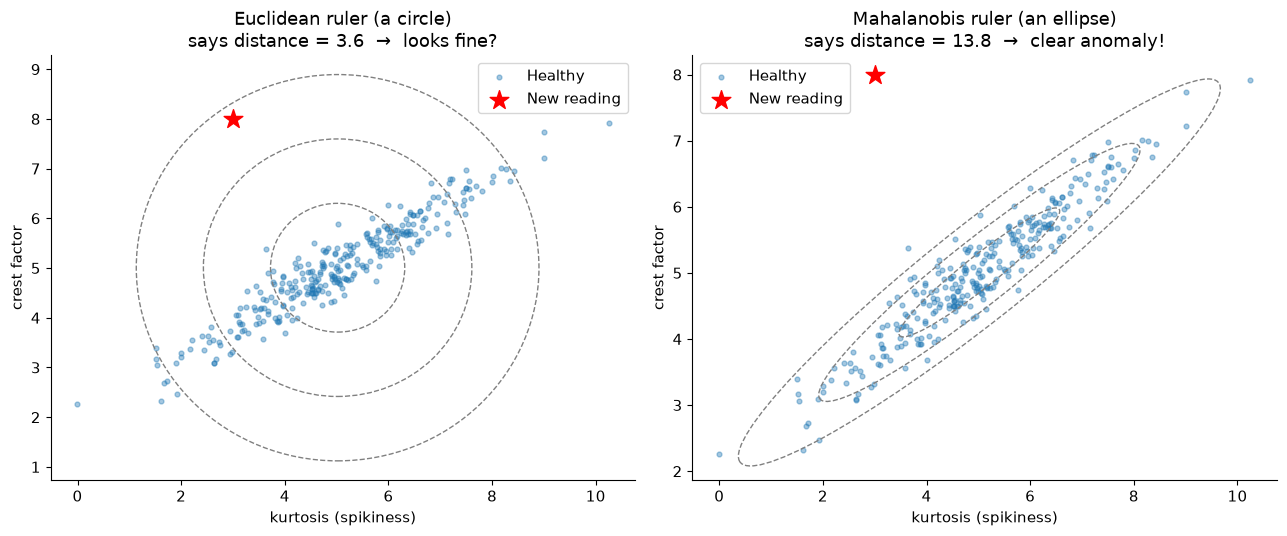

Same point, two verdicts:
  Euclidean distance    =  3.61  (a plain circle -> 'not far, probably fine')
  Mahalanobis distance  = 13.82  (respects the shape -> 'this breaks the pattern!')


In [2]:
# Build a "healthy" cloud where two features are positively correlated
n = 300
mean_true = [5.0, 5.0]
cov_true = [[2.5, 1.5], [1.5, 1.0]]     # the same S we will use by hand in Part 2
healthy = np.random.multivariate_normal(mean_true, cov_true, n)

# One candidate point that sits NEAR the average but BREAKS the correlation
candidate = np.array([3.0, 8.0])        # the same x we test by hand in Part 2

mu = healthy.mean(axis=0)
S = np.cov(healthy.T)
S_inv = np.linalg.inv(S)

def euclid(x):      return np.sqrt(((x - mu) ** 2).sum())
def mahal(x):       d = x - mu; return np.sqrt(d @ S_inv @ d)

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: Euclidean view (circles)
ax[0].scatter(healthy[:, 0], healthy[:, 1], s=12, alpha=0.4, label="Healthy")
for r in (1, 2, 3):
    ax[0].add_patch(plt.Circle(mu, r * np.sqrt(S.diagonal().mean()),
                    fill=False, ls="--", color="gray"))
ax[0].scatter(*candidate, c="red", s=200, marker="*", zorder=5, label="New reading")
ax[0].set_title(f"Euclidean ruler (a circle)\nsays distance = {euclid(candidate):.1f}  →  looks fine?")
ax[0].set_xlabel("kurtosis (spikiness)"); ax[0].set_ylabel("crest factor"); ax[0].legend()

# Right: Mahalanobis view (ellipses following the shape)
ax[1].scatter(healthy[:, 0], healthy[:, 1], s=12, alpha=0.4, label="Healthy")
vals, vecs = np.linalg.eigh(S)
angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
for r in (1, 2, 3):
    ax[1].add_patch(Ellipse(mu, 2 * r * np.sqrt(vals[0]), 2 * r * np.sqrt(vals[1]),
                    angle=angle, fill=False, ls="--", color="gray"))
ax[1].scatter(*candidate, c="red", s=200, marker="*", zorder=5, label="New reading")
ax[1].set_title(f"Mahalanobis ruler (an ellipse)\nsays distance = {mahal(candidate):.1f}  →  clear anomaly!")
ax[1].set_xlabel("kurtosis (spikiness)"); ax[1].set_ylabel("crest factor"); ax[1].legend()

plt.tight_layout(); plt.show()

print(f"Same point, two verdicts:")
print(f"  Euclidean distance    = {euclid(candidate):5.2f}  (a plain circle -> 'not far, probably fine')")
print(f"  Mahalanobis distance  = {mahal(candidate):5.2f}  (respects the shape -> 'this breaks the pattern!')")

**What just happened?**

- **Left (Euclidean):** a circle around the average. By this ruler the ⭐ looks unremarkable — it's not
  especially far from the centre.
- **Right (Mahalanobis):** ellipses that follow the *shape* of healthy data. Now the ⭐ is far outside,
  because it has *high kurtosis but low crest* — it **breaks the correlation** every healthy point obeys.

That is the whole idea of condition monitoring: an anomaly isn't "far from average", it's **"far from
the pattern of normal"**. A fault often shows up as one sensor drifting out of step with the others.

---
# Part 2 — See it once by hand (the `D ≈ 13.34` example)

Before any library, let's do the entire computation by hand on **five points** — the exact example from
the slides. No black box.

**The formula:**  $D(x) = \sqrt{(x - \mu)^T\, S^{-1}\, (x - \mu)}$

- $x$ — the point we're testing
- $\mu$ — the mean (centre) of healthy data
- $S$ — the covariance matrix (the *shape* of the cloud)
- $S^{-1}$ — the "shape correction" that un-tilts the ellipse

In [3]:
# The 5 healthy training points from the slides
X = np.array([[7, 6],
              [3, 4],
              [6, 6],
              [4, 4],
              [5, 5]], dtype=float)

# Step 1 — the mean
mu_hand = X.mean(axis=0)
print("Step 1 - mean vector mu =", mu_hand, " (i.e. (5, 5))")

# Step 2 — the covariance matrix (divide by n-1 = 4)
S_hand = np.cov(X.T)              # sample covariance
print("\nStep 2 - covariance matrix S =")
print(S_hand, "  (i.e. [[2.5, 1.5], [1.5, 1.0]])")

# Step 3 — invert it (the shape correction)
S_hand_inv = np.linalg.inv(S_hand)
print("\nStep 3 - inverse covariance S^-1 =")
print(S_hand_inv, "  (i.e. [[4, -6], [-6, 10]])")

# Step 4 — plug in the test point
x_test = np.array([3.0, 8.0])
d = x_test - mu_hand
D2 = d @ S_hand_inv @ d
D = np.sqrt(D2)
D_euclid = np.sqrt((d ** 2).sum())

print("\nStep 4 - test point x = (3, 8)")
print(f"   deviation (x - mu)      = {d}")
print(f"   squared Mahalanobis D^2 = {D2:.1f}   (i.e. 178)")
print(f"   MAHALANOBIS  D          = {D:.2f}    <- screaming anomaly")
print(f"   (for contrast) EUCLIDEAN = {D_euclid:.2f}    <- would have let it through)")

Step 1 - mean vector mu = [5. 5.]  (i.e. (5, 5))

Step 2 - covariance matrix S =
[[2.5 1.5]
 [1.5 1. ]]   (i.e. [[2.5, 1.5], [1.5, 1.0]])

Step 3 - inverse covariance S^-1 =
[[ 4. -6.]
 [-6. 10.]]   (i.e. [[4, -6], [-6, 10]])

Step 4 - test point x = (3, 8)
   deviation (x - mu)      = [-2.  3.]
   squared Mahalanobis D^2 = 178.0   (i.e. 178)
   MAHALANOBIS  D          = 13.34    <- screaming anomaly
   (for contrast) EUCLIDEAN = 3.61    <- would have let it through)


**Same point, two verdicts — again.** Euclidean sees `(3, 8)` as only ~1.6× farther than a truly
normal point; Mahalanobis sees it as ~9× farther, because `(3, 8)` breaks the positive correlation the
healthy data follows.

**The magic threshold.** For data from a multivariate-normal distribution, *squared* Mahalanobis
distance follows a **chi-squared** distribution with degrees of freedom = number of features. That gives
us a principled cut-off instead of a guess.

In [4]:
p = 2                      # number of features
for alpha in (0.05, 0.01, 0.001):
    thr = np.sqrt(chi2.ppf(1 - alpha, df=p))
    print(f"  alpha={alpha:<6}  ->  flag if D > {thr:.2f}   "
          f"({'test point IS flagged' if D > thr else 'test point NOT flagged'})")

print("\nLower alpha = stricter = fewer false alarms but more missed faults.")
print("This single knob is a BUSINESS decision, not a maths one. Hold that thought for Part 7.")

  alpha=0.05    ->  flag if D > 2.45   (test point IS flagged)
  alpha=0.01    ->  flag if D > 3.03   (test point IS flagged)
  alpha=0.001   ->  flag if D > 3.72   (test point IS flagged)

Lower alpha = stricter = fewer false alarms but more missed faults.
This single knob is a BUSINESS decision, not a maths one. Hold that thought for Part 7.


#### Discussion (30 seconds)
At $\alpha = 0.001$ (very strict) we still flag this point — it is *that* anomalous. For a
safety-critical system, would you run strict (few alarms, risk missing faults) or loose (catch
everything, more false alarms)? **There is no universal right answer — it's a policy choice you must be
able to defend.**

---
# Part 3 — The data: a vehicle with five vibration sensors

Now we leave the toy example and load the **real vehicle-health dataset**. Five vertical-acceleration
sensors, sampled at 200 Hz (one reading every 5 ms), over a **rough** road surface:

| Sensor | Position |
|---|---|
| `FR_LH` | Front-Left |
| `FR_RH` | Front-Right |
| `RR_LH` | Rear-Left |
| `RR_RH` | Rear-Right |
| `Cabin` | Cabin |

Three datasets, all from the **same vehicle**:
- **Healthy-Train** — healthy-condition data we *learn "normal"* from. The model only ever sees this.
- **Healthy-Check** — a *different* slice of healthy data. Should look normal → the model should stay quiet.
- **Faulty-Run** — the run during which a **front-end fault developed.** Should look anomalous → the model
  should raise its hand, especially on the front sensors.

> The next cell hunts for the real data folder. If it can't find it, it *simulates* data with the same
> structure — healthy runs, and a faulty run where the two **front** sensors develop the spiky,
> high-energy signature of a mechanical fault. Either way, the rest of the notebook is identical.

> **Rail analogy to keep in your head:** `Healthy-Train` = the fleet's normal baseline; `Healthy-Check` =
> a healthy loco reporting in; `Faulty-Run` = a wagon whose front axle-box bearing is starting to go.

In [5]:
import os, glob

SENSORS = ["FR_LH", "FR_RH", "RR_LH", "RR_RH", "Cabin"]

def _find_data_dir():
    candidates = [
        "Input_Data_Files",
        "../Anomaly-Detection-Using-Mahalanobis-Distance-Autoencoder-Automated-Vehicle-Health-Monitoring/Input_Data_Files",
        "Anomaly-Detection-Using-Mahalanobis-Distance-Autoencoder-Automated-Vehicle-Health-Monitoring/Input_Data_Files",
    ]
    for c in candidates:
        if os.path.exists(os.path.join(c, "RoughDataTrain.csv")):
            return c
    hits = glob.glob("**/RoughDataTrain.csv", recursive=True)
    return os.path.dirname(hits[0]) if hits else None

def _load_csv(path):
    df = pd.read_csv(path)
    # first column is a timestamp/index (sometimes unnamed) -> drop it, keep the 5 sensors
    cols = [c for c in df.columns if any(s in c for s in SENSORS)]
    df = df[cols].copy()
    df.columns = SENSORS
    return df.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

def _simulate(n, faulty_front=False):
    # Faithful stand-in: rough-road vibration on 5 sensors.
    # A front-end fault adds sharp periodic impacts (higher energy + spikiness) to FR_LH/FR_RH.
    rng = np.random.default_rng(0 if not faulty_front else 7)
    base = {"FR_LH": 1.6, "FR_RH": 1.7, "RR_LH": 0.8, "RR_RH": 0.7, "Cabin": 0.5}
    out = {}
    t = np.arange(n)
    for s in SENSORS:
        sig = rng.normal(0, base[s], n)                      # broadband road vibration
        sig += 0.4 * np.sin(2 * np.pi * t / 11)              # gentle structural resonance
        if faulty_front and s in ("FR_LH", "FR_RH"):
            # bearing-style impacts: sharp spikes every ~9 samples, growing over time
            impacts = np.zeros(n)
            idx = np.arange(0, n, 9)
            impacts[idx] = rng.normal(0, 1, len(idx)) * (3.5 * (1 + t[idx] / n))
            sig = sig + impacts
        out[s] = sig
    return pd.DataFrame(out)

DATA_DIR = _find_data_dir()
if DATA_DIR:
    print(f"Real dataset found in: {DATA_DIR}\n")
    healthy_train_raw = _load_csv(os.path.join(DATA_DIR, "RoughDataTrain.csv"))
    healthy_check_raw = _load_csv(os.path.join(DATA_DIR, "RoughDataTest_Feb.csv"))
    faulty_raw        = _load_csv(os.path.join(DATA_DIR, "RoughDataTest_March.csv"))
    DATA_SOURCE = "REAL"
else:
    print("Real dataset not found - generating a faithful synthetic stand-in (offline mode).\n")
    healthy_train_raw = _simulate(60000, faulty_front=False)
    healthy_check_raw = _simulate(60000, faulty_front=False)
    faulty_raw        = _simulate(60000, faulty_front=True)
    DATA_SOURCE = "SYNTHETIC"

for name, d in [("Healthy-Train", healthy_train_raw), ("Healthy-Check", healthy_check_raw),
                ("Faulty-Run (front-end fault)", faulty_raw)]:
    print(f"  {name:30s}: {len(d):>7,} readings x {d.shape[1]} sensors")

Real dataset found in: ../Anomaly-Detection-Using-Mahalanobis-Distance-Autoencoder-Automated-Vehicle-Health-Monitoring/Input_Data_Files



  Healthy-Train                 : 164,932 readings x 5 sensors
  Healthy-Check                 : 187,517 readings x 5 sensors
  Faulty-Run (front-end fault)  : 186,734 readings x 5 sensors


### Eyeball the raw signal first — never trust a model on data you haven't looked at

Let's plot a short slice of each front sensor for the healthy run and the faulty run.

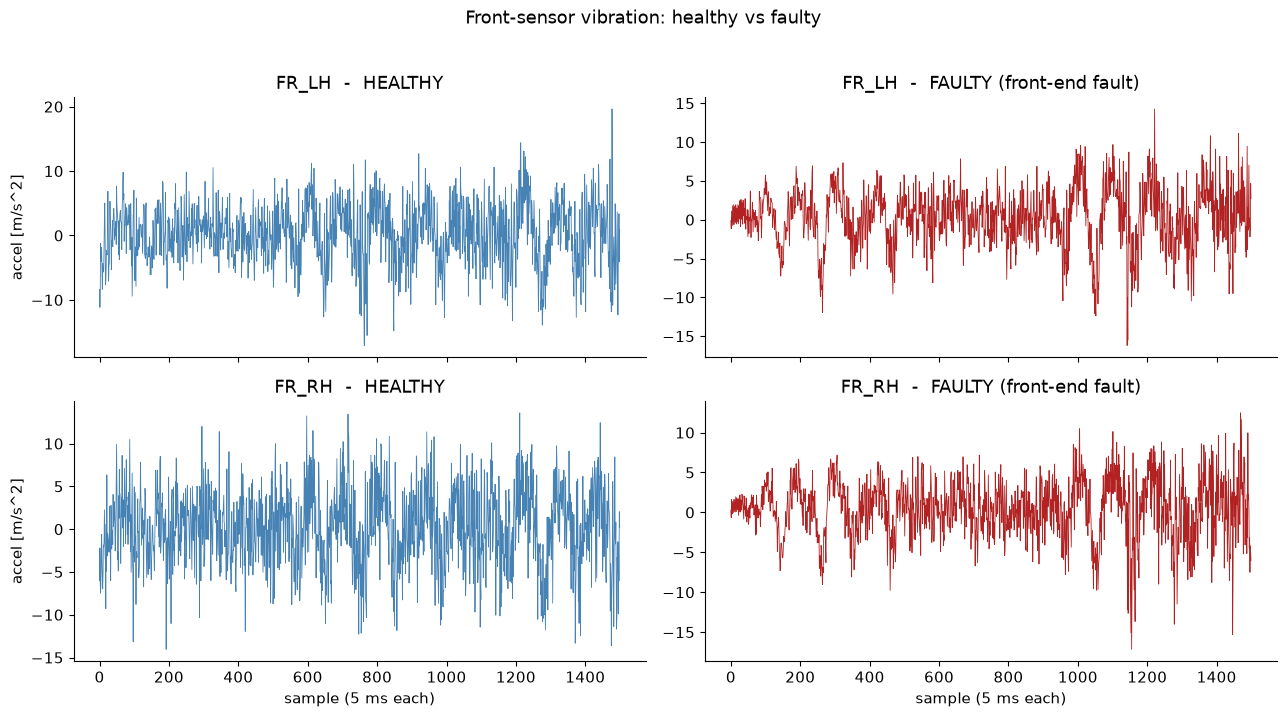

Look at the FAULTY (right) traces: sharper, taller, more erratic spikes.
That 'spikiness' is what a defect adds - and it's exactly what KURTOSIS measures.


In [6]:
slice_len = 1500
fig, ax = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for row, sensor in enumerate(["FR_LH", "FR_RH"]):
    ax[row, 0].plot(healthy_check_raw[sensor].values[:slice_len], lw=0.6, color="steelblue")
    ax[row, 0].set_title(f"{sensor}  -  HEALTHY")
    ax[row, 1].plot(faulty_raw[sensor].values[:slice_len], lw=0.6, color="firebrick")
    ax[row, 1].set_title(f"{sensor}  -  FAULTY (front-end fault)")
    ax[row, 0].set_ylabel("accel [m/s^2]")
for a in ax[1]:
    a.set_xlabel("sample (5 ms each)")
plt.suptitle("Front-sensor vibration: healthy vs faulty", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

print("Look at the FAULTY (right) traces: sharper, taller, more erratic spikes.")
print("That 'spikiness' is what a defect adds - and it's exactly what KURTOSIS measures.")

---
# Part 4 — Feature engineering: from a wall of numbers to 7 that matter

Raw vibration is impossible to reason about directly — 200 numbers a second, per sensor. So we slide a
**window** across the signal and, for each window, compute **7 time-domain features** that summarise its
*shape*:

| Feature | Plain meaning |
|---|---|
| `mean` | average level |
| `var` | spread / how much it moves |
| `skew` | lopsidedness |
| `kurtosis` | **spikiness — the star; jumps when sharp impacts appear** |
| `peak` | largest absolute value in the window |
| `rms` | overall energy / "loudness" |
| `crest` | peak ÷ rms — how tall the spikes are vs the average |

> **This is the most important idea in the session:** *features beat the model.* Get these numbers right
> and a simple detector shines. This mirrors the published study exactly (7 features per sensor).

In [7]:
def time_domain_features(series, window=2000, step=250):
    # Slide a window over one sensor's signal; return a DataFrame of 7 features per window.
    x = np.asarray(series, dtype=float)
    rows = []
    for i in range(0, len(x) - window + 1, step):
        w = x[i:i + window]
        rms = np.sqrt(np.mean(w ** 2))
        peak = np.max(np.abs(w))
        rows.append({
            "mean": w.mean(),
            "var": w.var(ddof=1),
            "skew": skew(w),
            "kurtosis": kurtosis(w),
            "peak": peak,
            "rms": rms,
            "crest": peak / rms if rms > 0 else 0.0,
        })
    return pd.DataFrame(rows)

FEATURES = ["mean", "var", "skew", "kurtosis", "peak", "rms", "crest"]

# Extract features for every sensor, for each dataset
def features_all_sensors(raw):
    return {s: time_domain_features(raw[s]) for s in SENSORS}

feat_healthy_train = features_all_sensors(healthy_train_raw)
feat_healthy_check = features_all_sensors(healthy_check_raw)
feat_faulty        = features_all_sensors(faulty_raw)

print("Feature windows per sensor:")
print(f"  Healthy-Train : {len(feat_healthy_train['FR_LH'])} windows")
print(f"  Healthy-Check : {len(feat_healthy_check['FR_LH'])} windows")
print(f"  Faulty-Run    : {len(feat_faulty['FR_LH'])} windows")
print("\nExample - first few feature rows for FR_LH (front-left), Healthy-Train set:")
feat_healthy_train["FR_LH"].head()

Feature windows per sensor:
  Healthy-Train : 652 windows
  Healthy-Check : 743 windows
  Faulty-Run    : 739 windows

Example - first few feature rows for FR_LH (front-left), Healthy-Train set:


,mean,var,skew,kurtosis,peak,rms,crest
0,0.805269,17.273123,-0.270346,0.460825,18.691126,4.232369,4.416233
1,0.683561,16.839261,-0.223275,0.522538,18.691126,4.159098,4.494034
2,0.679160,15.455854,-0.152172,0.632370,18.691126,3.988657,4.686070
3,0.550703,14.714156,-0.130620,0.822144,18.691126,3.874283,4.824409
4,0.533184,13.564542,-0.142043,1.041379,18.691126,3.720490,5.023835


### Does kurtosis actually separate healthy from faulty?

If our headline claim is true, the **kurtosis** of the front sensors should be visibly higher in the
faulty run than in the healthy run. Let's check before we model anything.

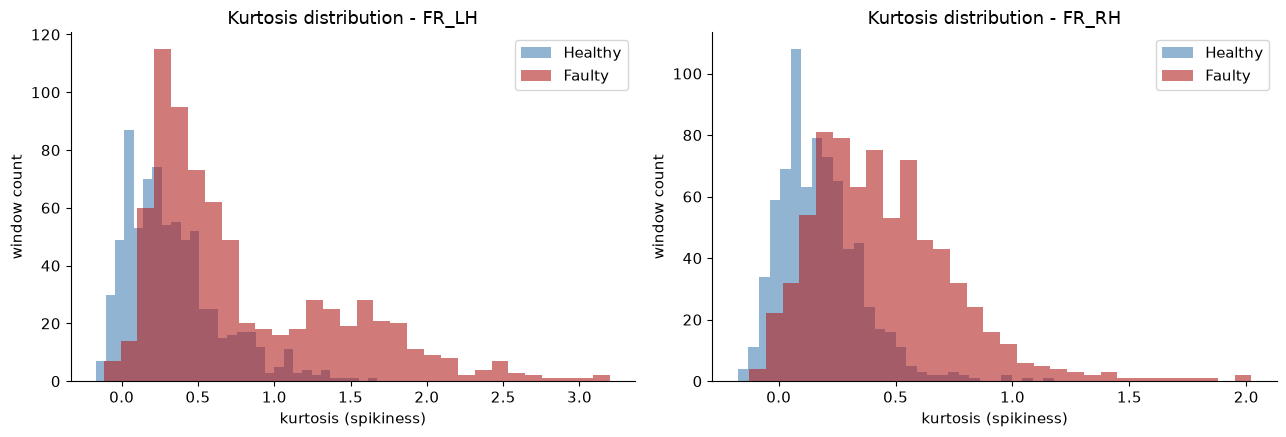

  FR_LH   mean kurtosis  Healthy=  0.33   Faulty=  0.79  <-- FRONT END, big jump
  FR_RH   mean kurtosis  Healthy=  0.18   Faulty=  0.45  <-- FRONT END, big jump
  RR_LH   mean kurtosis  Healthy= -0.09   Faulty= -0.09
  RR_RH   mean kurtosis  Healthy=  0.01   Faulty=  0.01
  Cabin   mean kurtosis  Healthy=  0.27   Faulty=  0.51


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for j, sensor in enumerate(["FR_LH", "FR_RH"]):
    ax[j].hist(feat_healthy_check[sensor]["kurtosis"], bins=30, alpha=0.6,
               label="Healthy", color="steelblue")
    ax[j].hist(feat_faulty[sensor]["kurtosis"], bins=30, alpha=0.6,
               label="Faulty", color="firebrick")
    ax[j].set_title(f"Kurtosis distribution - {sensor}")
    ax[j].set_xlabel("kurtosis (spikiness)"); ax[j].set_ylabel("window count"); ax[j].legend()
plt.tight_layout(); plt.show()

for sensor in SENSORS:
    kf = feat_healthy_check[sensor]["kurtosis"].mean()
    km = feat_faulty[sensor]["kurtosis"].mean()
    flag = "  <-- FRONT END, big jump" if sensor in ("FR_LH", "FR_RH") else ""
    print(f"  {sensor:6s}  mean kurtosis  Healthy={kf:6.2f}   Faulty={km:6.2f}{flag}")

---
# Part 5 — Learn "normal", then score: single-sensor Mahalanobis

Now the core move of condition monitoring:

1. On the **Healthy-Train** features, learn the *shape* of normal — the mean $\mu$ and covariance $S$.
2. For every window in **Healthy-Check** and the **Faulty-Run**, compute its **Mahalanobis distance**
   from that healthy shape.
3. Healthy windows should score **low**; faulty windows should score **high**.

We use scikit-learn's robust covariance (`MinCovDet`) so a few noisy training windows can't distort the
model — a small but important production detail. **In code, the whole computation is one `.mahalanobis()`
call.**

In [9]:
def fit_healthy_model(train_features):
    # Learn the healthy 7-D shape for one sensor. Returns a fitted robust-covariance model + scaler.
    Xtr = train_features[FEATURES].values
    mu = Xtr.mean(axis=0)
    sd = Xtr.std(axis=0) + 1e-9
    Xtr_scaled = (Xtr - mu) / sd
    model = MinCovDet(random_state=0).fit(Xtr_scaled)   # robust mean + covariance
    return {"model": model, "mu": mu, "sd": sd}

def mahal_scores(fitted, features):
    X = (features[FEATURES].values - fitted["mu"]) / fitted["sd"]
    return np.sqrt(fitted["model"].mahalanobis(X))      # distance (not squared)

# Fit one model per sensor on healthy training data
models = {s: fit_healthy_model(feat_healthy_train[s]) for s in SENSORS}

# Score the healthy-check and faulty runs for every sensor
score_healthy = {s: mahal_scores(models[s], feat_healthy_check[s]) for s in SENSORS}
score_faulty  = {s: mahal_scores(models[s], feat_faulty[s])        for s in SENSORS}

# Threshold: learn it from the HEALTHY TRAINING data (99th percentile of healthy distances).
# This is the practical alternative to the chi-squared rule - it makes no normality assumption
# and simply says "alarm when an asset is more extreme than 99% of known-healthy behaviour".
train_scores = {s: mahal_scores(models[s], feat_healthy_train[s]) for s in SENSORS}
THRESH = {s: np.percentile(train_scores[s], 99) for s in SENSORS}

print("Median Mahalanobis distance per sensor (higher = more anomalous):\n")
print(f"  {'sensor':8s}{'Healthy':>14s}{'Faulty':>14s}")
for s in SENSORS:
    tag = "  <-- front end" if s in ("FR_LH", "FR_RH") else ""
    print(f"  {s:8s}{np.median(score_healthy[s]):>14.2f}{np.median(score_faulty[s]):>14.2f}{tag}")

Median Mahalanobis distance per sensor (higher = more anomalous):

  sensor         Healthy        Faulty
  FR_LH             4.01         49.58  <-- front end
  FR_RH             4.03         22.78  <-- front end
  RR_LH             3.80          6.55
  RR_RH             3.72          7.23
  Cabin             3.37         12.14


### Plot the distance for the front-left sensor — the picture the controller sees

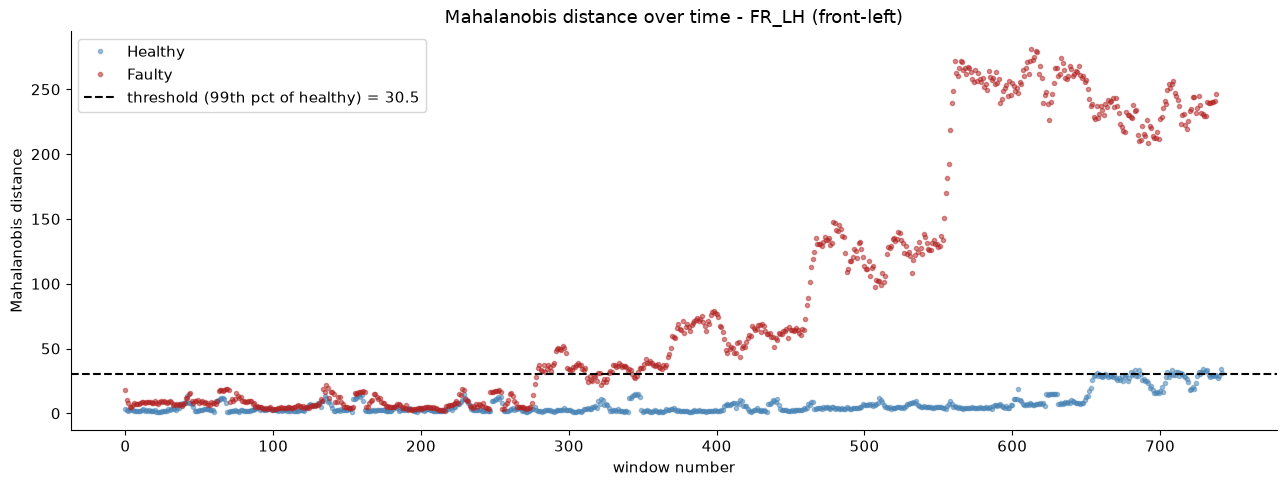

Windows above threshold on FR_LH:
   Healthy :   2.6%   (ideally low - these are false alarms)
   Faulty  :  59.9%   (ideally high - these are correct catches)


In [10]:
sensor = "FR_LH"
# threshold learned from healthy training data (99th percentile)
thr = THRESH[sensor]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(score_healthy[sensor], "o", ms=3, alpha=0.5, color="steelblue", label="Healthy")
ax.plot(score_faulty[sensor], "o", ms=3, alpha=0.5, color="firebrick", label="Faulty")
ax.axhline(thr, color="black", ls="--", label=f"threshold (99th pct of healthy) = {thr:.1f}")
ax.set_title(f"Mahalanobis distance over time - {sensor} (front-left)")
ax.set_xlabel("window number"); ax.set_ylabel("Mahalanobis distance"); ax.legend()
plt.tight_layout(); plt.show()

healthy_flag = (score_healthy[sensor] > thr).mean() * 100
faulty_flag = (score_faulty[sensor] > thr).mean() * 100
print(f"Windows above threshold on {sensor}:")
print(f"   Healthy : {healthy_flag:5.1f}%   (ideally low - these are false alarms)")
print(f"   Faulty  : {faulty_flag:5.1f}%   (ideally high - these are correct catches)")

**Read the picture like a controller.** The blue (healthy) points hug the bottom, mostly below the
dashed line. The red (faulty) points climb well above it — the front-left sensor is telling us something
changed. The model was never told about the fault; it simply learned "healthy" and the fault revealed
itself as *distance from normal*.

---
# Part 6 — All five sensors at once: localising the fault

A single sensor tells you *something* is wrong. Fusing **all five** tells you *where*. Let's compare the
"anomaly rate" (share of windows above the threshold) across every sensor, for the healthy vs faulty run.

This is the difference between "an axle is unhappy" and "**the front-left and front-right are unhappy —
check the front bogie**". Localisation is what turns a score into an actionable inspection.

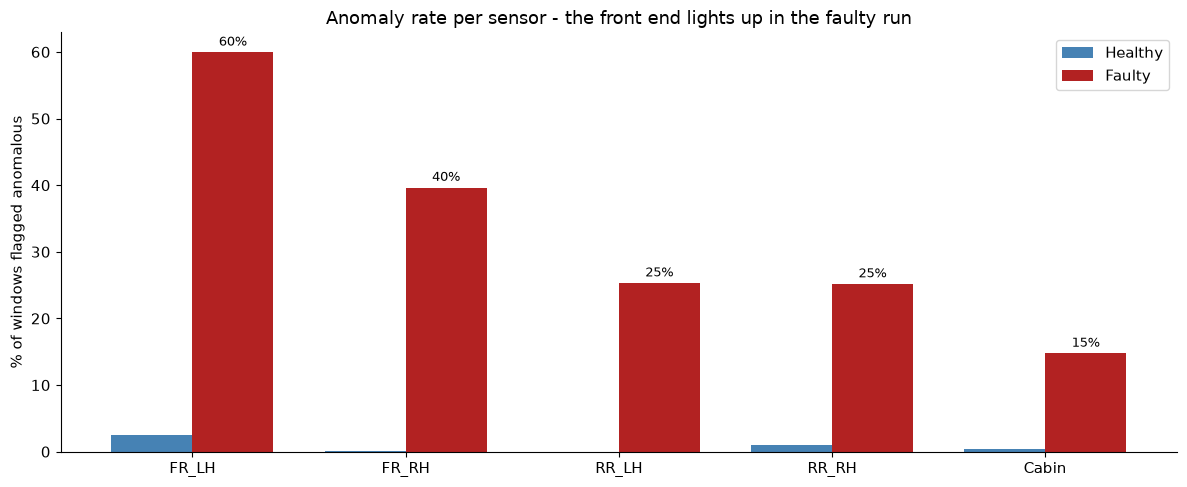

Interpretation:
  - Healthy run: all sensors show a LOW flag rate (occasional false alarms).
  - Faulty run: the FRONT sensors (FR_LH, FR_RH) spike far above the rest.
  - The model localises the problem to the front end - matching the known fault.


In [11]:
healthy_rates = [(score_healthy[s] > THRESH[s]).mean() * 100 for s in SENSORS]
faulty_rates  = [(score_faulty[s]  > THRESH[s]).mean() * 100 for s in SENSORS]

x = np.arange(len(SENSORS)); w = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, healthy_rates, w, label="Healthy", color="steelblue")
ax.bar(x + w/2, faulty_rates, w, label="Faulty", color="firebrick")
ax.set_xticks(x); ax.set_xticklabels(SENSORS)
ax.set_ylabel("% of windows flagged anomalous")
ax.set_title("Anomaly rate per sensor - the front end lights up in the faulty run")
ax.legend()
for i, v in enumerate(faulty_rates):
    ax.text(i + w/2, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print("Interpretation:")
print("  - Healthy run: all sensors show a LOW flag rate (occasional false alarms).")
print("  - Faulty run: the FRONT sensors (FR_LH, FR_RH) spike far above the rest.")
print("  - The model localises the problem to the front end - matching the known fault.")

### The manager's summary table
One row per sensor: what a dashboard would surface to the DRM / IRMS officer.

In [12]:
summary = pd.DataFrame({
    "Sensor": SENSORS,
    "Position": ["Front-Left", "Front-Right", "Rear-Left", "Rear-Right", "Cabin"],
    "Healthy median dist": [round(np.median(score_healthy[s]), 1) for s in SENSORS],
    "Faulty median dist": [round(np.median(score_faulty[s]), 1) for s in SENSORS],
    "Faulty flagged %": [round((score_faulty[s] > THRESH[s]).mean() * 100, 1) for s in SENSORS],
})
summary["Verdict"] = np.where(summary["Faulty flagged %"] > 25, "INVESTIGATE", "ok")
summary

,Sensor,Position,Healthy median dist,Faulty median dist,Faulty flagged %,Verdict
0,FR_LH,Front-Left,4.0,49.6,59.9,INVESTIGATE
1,FR_RH,Front-Right,4.0,22.8,39.6,INVESTIGATE
2,RR_LH,Rear-Left,3.8,6.5,25.3,INVESTIGATE
3,RR_RH,Rear-Right,3.7,7.2,25.2,INVESTIGATE
4,Cabin,Cabin,3.4,12.1,14.7,ok


---
# Part 7 — From score to decision: the cost of being wrong

A distance is not a decision. The moment you pick a threshold, you are trading off **two kinds of
mistake** — and they do *not* cost the same:

| Mistake | What it is | Roughly costs |
|---|---|---|
| **False alarm** (false positive) | flag a healthy asset | an unnecessary inspection / delay — thousands |
| **Missed fault** (false negative) | wave through a faulty asset | lives and crores — the one that derails |

Let's make the threshold a **dial** and watch the two error counts move. This is the single most
important slide for a decision-maker.

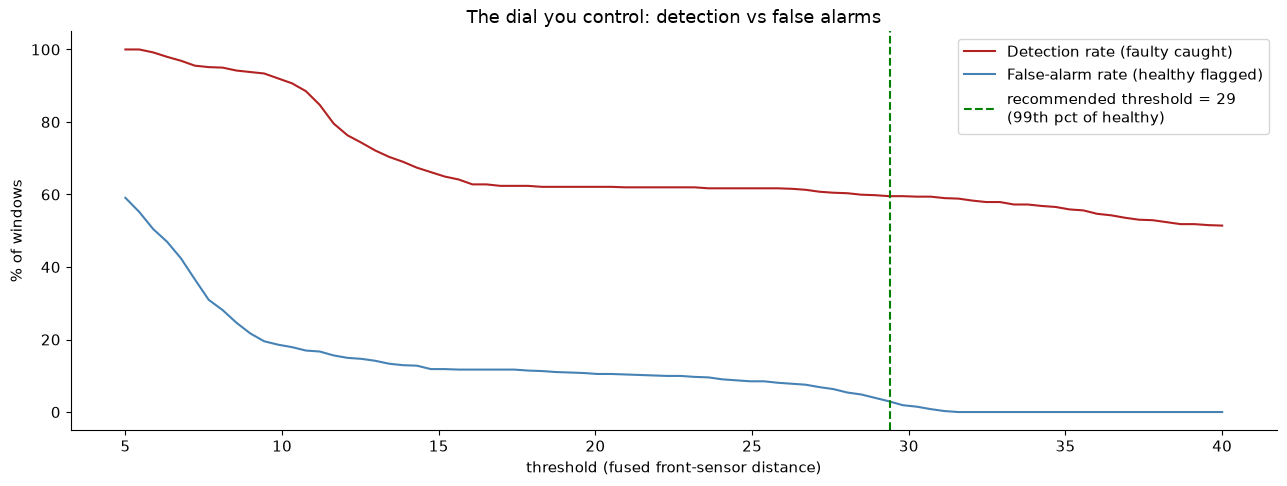

At the recommended threshold (29):
   false-alarm rate (healthy flagged) =   3.0%   (a handful of nuisance alerts)
   detection rate   (faulty flagged)  =  59.5%   (of faulty-run windows)

Two things to sit with:
  1. The faulty vehicle is flagged on 60% of its windows - so across a run it
     is caught many times over. You only need ONE catch to pull it in for inspection.
  2. Lower the dial and you catch the fault EARLIER (weaker signals) but cry wolf more.
     Raise it and alerts are rock-solid but you see the fault later. A missed fault
     costs ~1000x a false alarm - so you lean towards catching early. WHERE you draw
     that line is a POLICY judgement you must defend, not an output of the maths.


In [13]:
# Fuse the two FRONT sensors (take the worse of the two), then smooth over ~10 windows.
# Smoothing means we alarm on a SUSTAINED trend, not one noisy window - exactly what you'd
# do in the field, where a single spike is noise but a rising trend is a warning.
def fused_front(score_dict, k=10):
    n = min(len(score_dict["FR_LH"]), len(score_dict["FR_RH"]))
    worse = np.maximum(score_dict["FR_LH"][:n], score_dict["FR_RH"][:n])
    return pd.Series(worse).rolling(k, min_periods=1).mean().values

train_fused   = fused_front(train_scores)    # known-healthy baseline
healthy_fused = fused_front(score_healthy)   # HEALTHY -> any flag = false alarm
faulty_fused  = fused_front(score_faulty)    # FAULTY  -> we want to detect these

# Sweep the threshold and record the two rates the officer actually cares about.
thresholds = np.linspace(5, 40, 80)
false_alarm_rate = [100 * (healthy_fused > t).mean() for t in thresholds]  # % healthy flagged
detection_rate   = [100 * (faulty_fused  > t).mean() for t in thresholds]  # % faulty caught

# A sensible, defensible operating point: the 99th percentile of KNOWN-HEALTHY behaviour.
op = np.percentile(train_fused, 99)
op_fa = 100 * (healthy_fused > op).mean()
op_det = 100 * (faulty_fused > op).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(thresholds, detection_rate, color="firebrick", label="Detection rate (faulty caught)")
ax.plot(thresholds, false_alarm_rate, color="steelblue", label="False-alarm rate (healthy flagged)")
ax.axvline(op, color="green", ls="--",
           label=f"recommended threshold = {op:.0f}\n(99th pct of healthy)")
ax.set_xlabel("threshold (fused front-sensor distance)"); ax.set_ylabel("% of windows")
ax.set_title("The dial you control: detection vs false alarms")
ax.legend(); plt.tight_layout(); plt.show()

print(f"At the recommended threshold ({op:.0f}):")
print(f"   false-alarm rate (healthy flagged) = {op_fa:5.1f}%   (a handful of nuisance alerts)")
print(f"   detection rate   (faulty flagged)  = {op_det:5.1f}%   (of faulty-run windows)")
print()
print("Two things to sit with:")
print(f"  1. The faulty vehicle is flagged on {op_det:.0f}% of its windows - so across a run it")
print("     is caught many times over. You only need ONE catch to pull it in for inspection.")
print("  2. Lower the dial and you catch the fault EARLIER (weaker signals) but cry wolf more.")
print("     Raise it and alerts are rock-solid but you see the fault later. A missed fault")
print("     costs ~1000x a false alarm - so you lean towards catching early. WHERE you draw")
print("     that line is a POLICY judgement you must defend, not an output of the maths.")

#### Discussion — the decision only a human makes
1. Would you run the same threshold for a **passenger** train as for a **freight** wagon? The cost of a
   missed fault differs — so perhaps the dial should too.
2. Push the threshold too low and you get *alarm fatigue* — people stop trusting the system. Too high and
   you spot the fault too late. **Where you set this dial is a policy you must defend in an inquiry.**
3. Who signs off on that number in your organisation — the data team, the DRM, the zonal HQ? *(Hold this
   for the governance section.)*

---
# Part 8 — When Mahalanobis breaks, and what comes next

No method is universal. Three things a decision-maker should know:

1. **It assumes one elliptical "normal".** Real assets have *multiple* normal modes — rough vs smooth
   road, peak vs off-peak. That is *exactly* why this study **splits rough and smooth surfaces** and
   models them separately. Mixing them would make "normal" meaningless.
2. **It's sensitive to dirty training data.** One bad batch of "healthy" data poisons the mean and
   covariance — hence robust covariance (`MinCovDet`).
3. **For complex signals, let the machine learn the features.** An **Autoencoder** (a small neural
   network) learns "normal" directly from the raw vibration — no hand-crafted features needed — and flags
   anything it can't reconstruct well. The companion research applies exactly this as a second model.

**The trajectory ahead:** detection → *prognosis* (how many days of life left?) → digital twins →
LLM/agentic interfaces that let an officer simply *ask* the fleet how it's feeling. Your job isn't to
build these — it's to be the officer who asks them the right questions.

---
# Wrap-up — what to carry out of the room

1. **Anomaly detection = learn "normal", flag the rest.** We never needed labelled faults — only plenty
   of healthy data, which every railway has in abundance.
2. **Mahalanobis distance is a *smart* ruler.** It respects how features move together, so it catches a
   sensor that drifts *out of step* even when no single number looks extreme. (`D ≈ 13.34`, by hand.)
3. **Features beat the model.** Seven simple numbers per sensor — with **kurtosis** the star — carried
   the whole fault signature.
4. **Fusion localises.** Five sensors together pointed straight at the *front end* — the actual site of
   the breakdown.
5. **The threshold is a decision, not a calculation.** A missed fault dwarfs a false alarm, so you tune
   to over-warn — and you own, and defend, that choice.

**The model raised its hand. You made the call.** That is the job — and it doesn't change whether the
asset is a test vehicle, a Rajdhani bogie, or the next thing they bolt a sensor to.

> **Attribution.** Case study data & methods: Thakkar, K., Hemachandra, N., Singh, T. R. (2026),
> "Anomaly Detection Methods: Application to Automated Vehicle Health Monitoring", *Data Science for
> Modeling Managerial and Socioeconomic Problems*, Springer. IIM Kozhikode MDP.